# Exploratory Analysis

This is a term that's used to describe a general process of getting to know a dataset from scratch. It's not a specific process, but more a collection of ideas and strategies that someone can use to start a data analysis process. It's meant to be the way you get a general picture of what's in your data so that you can decide what areas are worth following up on, and what is missing.

For our purposes, here's how we're defining exploratory analysis:

1. Know where your data comes from

2. Know how your data is structured

3. Get some basic statistics

<hr>

## Know where your data comes from

At this point, you should have a dataset you'd like to explore. Respond to the questions in the first part of your Week 7 Journal in Blackboard - you will likely need to search online for some answers!

## Know how it's structured

First, look at the data dictionary. What kind of features/columns are there? Are they structured as numerical data, categorical data, or something else? Why did the dataset builders collect the data they did? Did they leave out any type of data that could be important?


You have looked for missing data before (Climate Data Part 1). As for looking at the number of columns and rows, you can use the `df.shape` call, and also `head()` to see just columns. You can also see how many unique values there are in a column by making a call to `df['column_name'].value_counts()`. Here's a cheat sheet of Pandas calls you can use to look at your data: https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf.

Use the code block below to print out some statistics on the shape of your data. Don't forget to: 1) add your file to the notebook, 2) import pandas, and 3) read your csv into a dataframe first!

In [ ]:
# write code here.
import pandas as pd

df = pd.read_csv('synthetic_coffee_health_10000.csv')

df.head()


,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1



After you've finished, answer the questions in the second part of your Week 7 Journal.

## Get some basic statistics

This is the last part of our exploratory analysis, and it's a bit more open ended. There are a lot of different ways you can get some basic statistics on your dataset, depending on whether you are looking at numerical data, or categorical data. For both, see some of the useful functions below. You can also check out some other functions in the cheat sheet https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf.

For numerical data, remember that one thing you can do is create a correlation matrix - this will give a high level overview of relationships between columns. Remember that you already used this technique in Climate Data Part 1 - you can use that as a reference.  

In [ ]:
# Numerical Data
# Select numerical columns (excluding unique identifier 'ID')
numerical_df = df.select_dtypes(include=['number']).drop(columns=['ID'])

# df.mean() - displays the average value of each column
print("Mean Values:\n", numerical_df.mean())

# df.median() - displays the median value of each column
print("\nMedian Values:\n", numerical_df.median())

# df.std() - displays the standard deviation of each column
print("\nStandard Deviation:\n", numerical_df.std())

# Correlation Matrix - High level overview of relationships
corr_matrix = numerical_df.corr()
print("\nCorrelation Matrix:\n", corr_matrix)

# Categorical Data
# df.describe(include=['object']) - displays count, unique, and top of each column
print("\nCategorical Summary:\n", df.describe(include=['object']))

Mean Values:
 Age                         34.94910
Coffee_Intake                2.50923
Caffeine_mg                238.41101
Sleep_Hours                  6.63622
BMI                         23.98686
Heart_Rate                  70.61780
Physical_Activity_Hours      7.48704
Smoking                      0.20040
Alcohol_Consumption          0.30070
dtype: float64

Median Values:
 Age                         34.0
Coffee_Intake                2.5
Caffeine_mg                235.4
Sleep_Hours                  6.6
BMI                         24.0
Heart_Rate                  71.0
Physical_Activity_Hours      7.5
Smoking                      0.0
Alcohol_Consumption          0.0
dtype: float64

Standard Deviation:
 Age                         11.160939
Coffee_Intake                1.450248
Caffeine_mg                137.748815
Sleep_Hours                  1.222055
BMI                          3.906411
Heart_Rate                   9.822951
Physical_Activity_Hours      4.315180
Smoking              

Once you have some basic statistics, answer the questions in part 3 of your week 7 journal.

## Visualization

After getting some basic statistics, it's time to see how visualizing the data might give you some additional insights. Import matplotlib as you have done in both the college data and climate data projects, and use it to look at your data in a new way.

In [ ]:
# import matplotlib below.
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipykernel_1478/812674932.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sleep_Quality', y='Sleep_Hours', data=df, order=['Poor', 'Fair', 'Good', 'Excellent'], palette='muted')


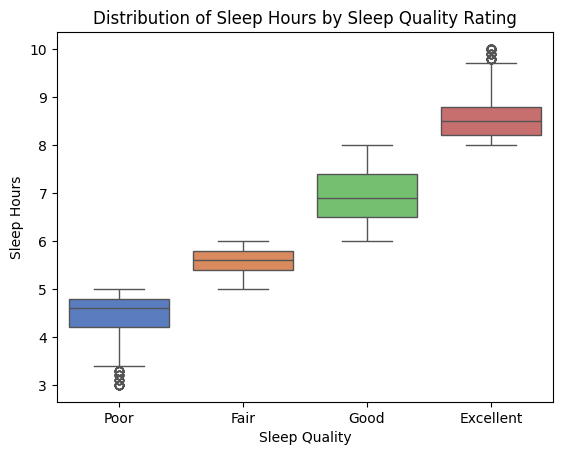

In [ ]:
# Create some visualizations for one or more columns of data in your dataframe. For your data:
# Boxplot: Sleep Hours by Sleep Quality
# This reveals how the "Poor/Good" label aligns with actual hours.
plt.clf()
sns.boxplot(x='Sleep_Quality', y='Sleep_Hours', data=df, order=['Poor', 'Fair', 'Good', 'Excellent'], palette='muted')
plt.title('Distribution of Sleep Hours by Sleep Quality Rating')
plt.xlabel('Sleep Quality')
plt.ylabel('Sleep Hours')
plt.savefig('boxplot_sleep_quality.png')

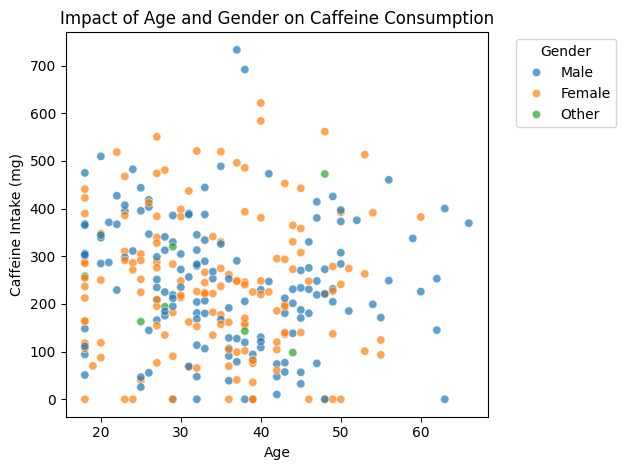

In [ ]:
# Scatter Plot: Age vs. Caffeine Intake (with Gender encoding)
# This combines three variables: Age (X), Caffeine (Y), and Gender (Color).
plt.clf()
# Sample 300 records for visual clarity in the scatter plot
sns.scatterplot(x='Age', y='Caffeine_mg', hue='Gender', data=df.sample(300), alpha=0.7)
plt.title('Impact of Age and Gender on Caffeine Consumption')
plt.xlabel('Age')
plt.ylabel('Caffeine Intake (mg)')
plt.legend(title='Gender', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('scatter_age_caffeine_gender.png')

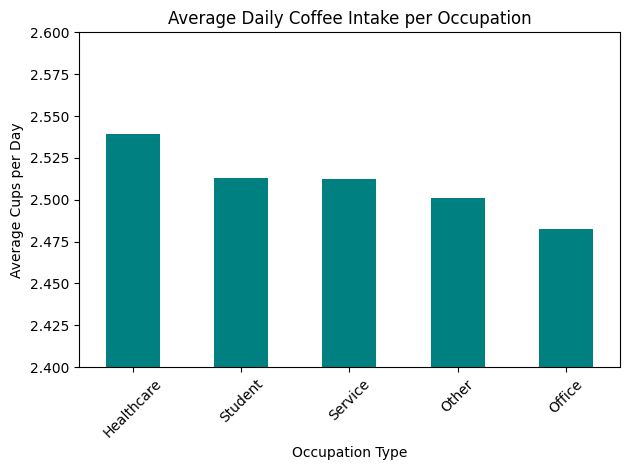

In [ ]:
# Bar Chart: Average Coffee Intake by Occupation
# Using a bar chart to compare the mean intake across different job categories.
plt.clf()
occ_coffee = df.groupby('Occupation')['Coffee_Intake'].mean().sort_values(ascending=False)
occ_coffee.plot(kind='bar', color='teal')
plt.title('Average Daily Coffee Intake per Occupation')
plt.xlabel('Occupation Type')
plt.ylabel('Average Cups per Day')
plt.ylim(2.4, 2.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('bar_occupation_coffee.png')

<Figure size 640x480 with 0 Axes>

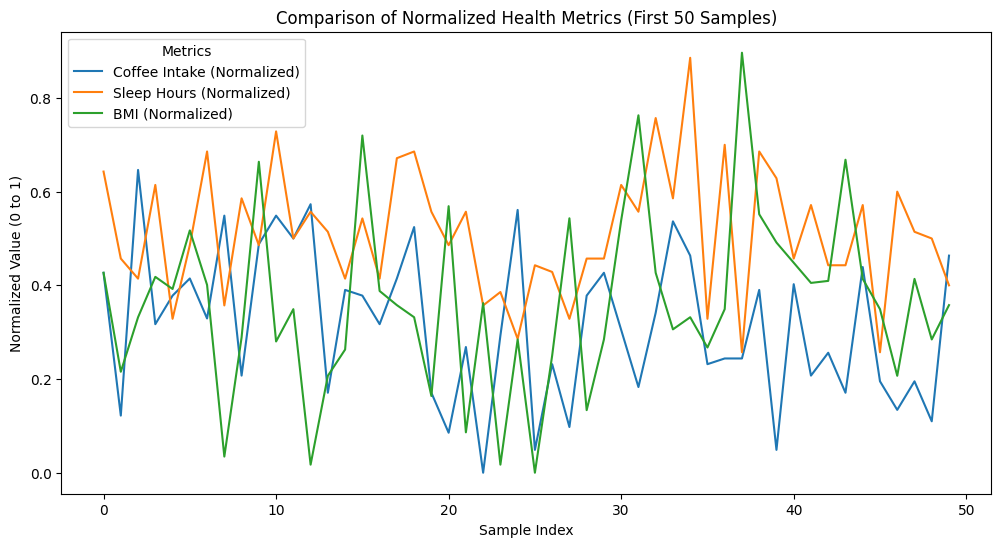

In [ ]:
# Create Normalized1, Normalized2, and Normalized3 columns
cols_to_normalize = ['Coffee_Intake', 'Sleep_Hours', 'BMI']
new_names = ['Normalized1', 'Normalized2', 'Normalized3']

for original, normalized in zip(cols_to_normalize, new_names):
    col_min = df[original].min()
    col_max = df[original].max()
    # Subtract min and divide by the range (max - min)
    df[normalized] = (df[original] - col_min) / (col_max - col_min)

# Select a subset of the data for a clearer line chart
df_subset = df.head(50).copy()
df_subset['Index'] = range(len(df_subset))

# Create the visualization using seaborn and matplotlib
plt.clf()
plt.figure(figsize=(12, 6))

# Plotting the three lines
sns.lineplot(x='Index', y='Normalized1', data=df_subset, label='Coffee Intake (Normalized)')
sns.lineplot(x='Index', y='Normalized2', data=df_subset, label='Sleep Hours (Normalized)')
sns.lineplot(x='Index', y='Normalized3', data=df_subset, label='BMI (Normalized)')

# Add legend, title, and axis labels
plt.title('Comparison of Normalized Health Metrics (First 50 Samples)')
plt.xlabel('Sample Index')
plt.ylabel('Normalized Value (0 to 1)')
plt.legend(title='Metrics')

# 5. Display the final chart
plt.savefig('normalized_lines_chart.png')

## Does machine learning help me understand my data?

Recall that in the Climate Data project, we were able to use regression to model data over time, and suggest where the data was trending. Does your data include columns that are worth exploring via regression?

A note on regression: while we used it before to look at data over time, it does not have to be used solely to look at data over time. Any numerical columns for which you'd like to model a relationship can be used for linear regression, or support vector regression

In [ ]:
# import scikit-learn below.
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

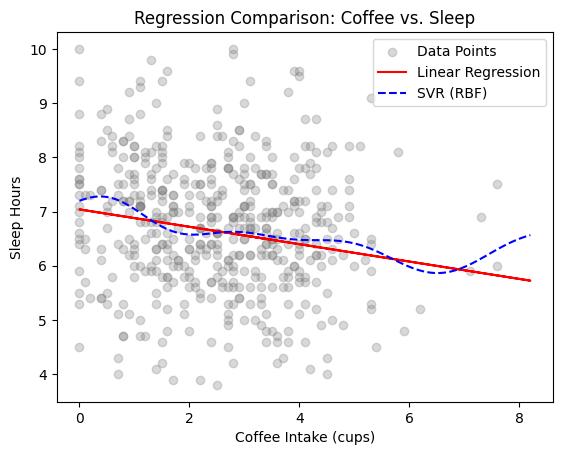

In [ ]:
# Add regression analyses, and graph the results. Look at your code from Climate Data parts 1 and 2 as a reference.
# Prepare features (X) and target (y)
import numpy as np
X = df[['Coffee_Intake']].values
y = df['Sleep_Hours'].values

# SVR requires data scaling to perform accurately
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

#Fit Linear Regression
lr_model = LinearRegression().fit(X, y)
y_pred_lr = lr_model.predict(X)

#Fit SVR (on a sample for efficiency)
svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr_model.fit(X_scaled[:1000], y_scaled[:1000])

# Generate smooth line for SVR visualization
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_range_scaled = scaler_X.transform(X_range)
y_range_svr = scaler_y.inverse_transform(svr_model.predict(X_range_scaled).reshape(-1, 1))

# Visualization
plt.scatter(X[:500], y[:500], alpha=0.3, color='gray', label='Data Points')
plt.plot(X, y_pred_lr, color='red', label='Linear Regression')
plt.plot(X_range, y_range_svr, color='blue', linestyle='--', label='SVR (RBF)')
plt.title('Regression Comparison: Coffee vs. Sleep')
plt.xlabel('Coffee Intake (cups)')
plt.ylabel('Sleep Hours')
plt.legend()
plt.savefig('regression_analysis_results.png')

<hr>

Once you have done some machine learning analysis, answer the questions in part 4 of your week 7 journal.